# YOLO — Session 2: Custom Training & CV Applications
### ITI · Instructor: Ahmed Abdelsalam

A pretrained YOLO knows 80 everyday objects. But what if you need to detect **your own** things — a specific product, a type of crop disease, safety helmets on a site? You **train YOLO on your own data**. Today you'll learn the full workflow and see where detection is used in the real world.

**Today's map**
1. Why train a custom model?
2. The data YOLO needs (images + labels + a config file)
3. The YOLO label format
4. How you get labels (annotation tools)
5. Training your model
6. Evaluating it (mAP, precision, recall)
7. Using your trained model
8. CV applications & YOLO's other tasks

> **Setup:** made for **Google Colab**. **Use a GPU runtime** for training: *Runtime → Change runtime type → GPU*.

## Setup — run this first

In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image
print("Ultralytics ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics ready.


## 1. Why train a custom model?

The pretrained model only knows COCO's 80 classes. Your project probably needs classes it has never seen:

- Counting a specific **product** on a shelf
- Spotting **defects** on a factory line
- Detecting **safety helmets** / PPE on a construction site
- Finding **tumors** in medical scans, **pests** on crops, etc.

For these, you train YOLO on **your own labelled images**. The good news: you don't start from zero — you **start from the pretrained model** (transfer learning again!) and adapt it. This is why custom YOLO training works with just hundreds of images instead of millions.

## 2. The data YOLO needs

To train, YOLO needs three things arranged in a standard layout:

1. **Images** — your photos (`.jpg`, `.png`).
2. **Labels** — one `.txt` file per image, listing the objects and their boxes.
3. **A config file** (`data.yaml`) — tells YOLO where the data is and what the classes are.

The folder layout:
```
my_dataset/
├── images/
│   ├── train/   img1.jpg, img2.jpg, ...
│   └── val/     img50.jpg, ...
├── labels/
│   ├── train/   img1.txt, img2.txt, ...
│   └── val/     img50.txt, ...
└── data.yaml
```
Each image has a **matching** label file with the same name (`img1.jpg` ↔ `img1.txt`).

### The `data.yaml` config
It's short — paths plus the class names:
```yaml
path: my_dataset
train: images/train
val: images/val

names:
  0: helmet
  1: person
  2: vest
```

## 3. The YOLO label format

Each line in a label `.txt` file describes **one object**:

```
class_id  x_center  y_center  width  height
```

- `class_id` — which class (matches the numbers in `data.yaml`).
- The other four are the box, **normalized to 0–1** (fraction of image width/height), measured from the **center** of the box.

Example — `img1.txt` with two objects:
```
0 0.51 0.42 0.20 0.35
1 0.77 0.60 0.15 0.25
```
That's "a class-0 object centered at 51% across, 42% down, 20% wide, 35% tall", and one class-1 object.

> Normalizing to 0–1 means the labels still work if you resize the image. You almost never write these by hand — a tool does it (next).

## 4. How you get labels (annotation)

You draw boxes on your images and a tool exports them in YOLO format:

| Tool | Notes |
|------|-------|
| **Roboflow** | web-based, most popular, exports YOLO format + can augment data |
| **CVAT** | powerful, open-source, good for teams |
| **labelImg** | simple desktop app, great for small projects |

The workflow is always: collect images → draw boxes → export as YOLO format → point `data.yaml` at it. For today's lab we'll use a ready-made sample dataset so we can focus on the **training** step.

In [5]:
!pip install roboflow -q

from roboflow import Roboflow

# IMPORTANT: Replace with your actual Roboflow API key and project details
# You can find your API key by logging into Roboflow, going to your workspace settings,
# and clicking "Roboflow API Key".
# The project URL is for your specific dataset, e.g., "your-workspace/your-project"
ROBOFLOW_API_KEY = "FNiKgfEjnt5Qzt76vctU"
ROBOFLOW_WORKSPACE = "augmented-startups"
ROBOFLOW_PROJECT = "football-player-detection-kucab"
ROBOFLOW_VERSION = 8 # e.g., 1 for version 1

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
dataset = project.version(ROBOFLOW_VERSION).download("yolov11") # Download in YOLOv11 format

# The dataset object's 'location' attribute points to the root directory of the downloaded dataset.
# The data.yaml file is typically located directly within this directory.
DATA_YAML_PATH = dataset.location + '/data.yaml'
# Read and print the content of the data.yaml file
with open(DATA_YAML_PATH, 'r') as f:
    yaml_content = f.read()
print(yaml_content)

loading Roboflow workspace...
loading Roboflow project...
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['football', 'player']

roboflow:
  workspace: augmented-startups
  project: football-player-detection-kucab
  version: 8
  license: CC BY 4.0
  url: https://universe.roboflow.com/augmented-startups/football-player-detection-kucab/dataset/8


## 5. Training your model

With the data ready, training is **one call**. Start from a pretrained model and let it adapt to your classes.

In [7]:
# Initialize the YOLO model (starting from a pretrained nano model)
model = YOLO("yolo11n.pt")

# Train the model using the downloaded dataset
# Adjust epochs, imgsz, and batch as needed based on your dataset and GPU memory.
# 'data' argument now points to the data.yaml file provided by Roboflow export.
print(f"Training with data from: {DATA_YAML_PATH}")
model.train(data=DATA_YAML_PATH, epochs=50, imgsz=640, batch=16)

Training with data from: /content/Football-Player-Detection-8/data.yaml
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Football-Player-Detection-8/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_395/66824508.py", line 8, in <cell line: 0>
    model.train(data=DATA_YAML_PATH, epochs=50, imgsz=640, batch=16)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 816, in train
    self.trainer.train()
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 241, in train
    self._do_train()
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 467, in _do_train
    loss, self.loss_items = self.model(batch)
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/

TypeError: object of type 'NoneType' has no len()

The key training settings:

| Setting | Meaning | Typical |
|---------|---------|---------|
| `data` | path to your `data.yaml` | your dataset |
| `epochs` | how many passes over the data | 50–100 |
| `imgsz` | image size for training | 640 |
| `batch` | images per step | 16 (lower if low memory) |

More epochs = more learning (up to a point). Bigger `imgsz` = more accurate but slower.

## 6. Evaluating your model

After training, how good is it? Detection uses a few standard numbers:

- **Precision** — of the boxes it predicted, how many were correct? (few false alarms)
- **Recall** — of the real objects, how many did it find? (few misses)
- **mAP** (mean Average Precision) — the main overall score, 0–1, higher is better. You'll see **mAP50** (a lenient overlap threshold) and **mAP50-95** (stricter, the headline metric).

Ultralytics prints these automatically during training and gives them via `model.val()`. You don't compute them by hand — just know **higher mAP = better detector**.

In [8]:
model2 = YOLO("/content/runs/detect/train/weights/best.pt")
metrics = model2.val()

# You can access specific metrics like this:
# print(f"Precision: {metrics.results_dict['metrics/precision(B)']}")
# print(f"Recall: {metrics.results_dict['metrics/recall(B)']}")
# print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']}")
# print(f"mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']}")

# The 'metrics' object itself will also print a summary when displayed or accessed.
print(metrics)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2210.9±756.1 MB/s, size: 88.8 KB)
val: Scanning /content/Football-Player-Detection-8/valid/labels.cache... 972 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 972/972 254.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 4.1it/s 15.0s
                   all        972       5407      0.911      0.671      0.758      0.439
              football        241        275      0.905      0.448      0.589      0.293
                player        936       5132      0.917      0.894      0.928      0.585
Speed: 1.6ms preprocess, 4.5ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index

## 7. Using your trained model

Once trained, it's just a YOLO model — you predict exactly like Session 1. The trained weights are saved to a file (`runs/detect/train/weights/best.pt`), and the in-memory `model` object is already trained.

```python
results = model("new_image.jpg")   # your custom detector at work
results[0].plot()                  # draw the boxes
```


image 1/1 /content/Football-Player-Detection-8/valid/images/54931_jpg.rf.e81c78836833a45d672ea358369a1566.jpg: 640x640 4 players, 11.5ms
Speed: 3.5ms preprocess, 11.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


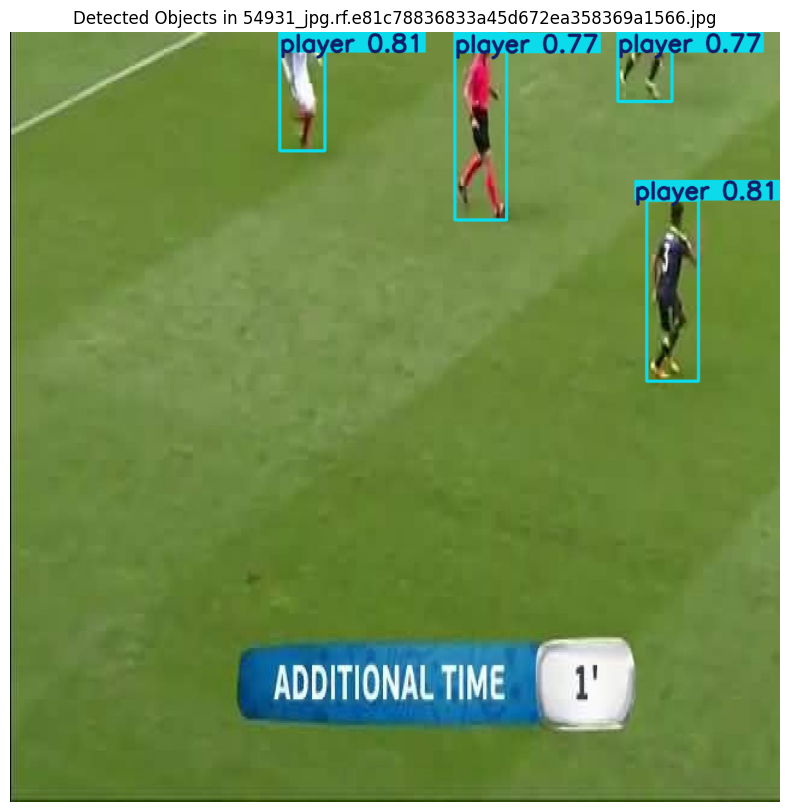

In [19]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Path to a new image for inference. Make sure this image is accessible.
# We will get one from the downloaded dataset's validation set.
val_images_path = dataset.location + '/valid/images'

new_image_path = None
if glob.glob(val_images_path + '/*.jpg'):
    new_image_path = glob.glob(val_images_path + '/*.jpg')[0]
elif glob.glob(val_images_path + '/*.png'):
    new_image_path = glob.glob(val_images_path + '/*.png')[0]
else:
    print("No JPG or PNG image found in the validation set. Please ensure your dataset has images.")

if new_image_path:
    # Make predictions
    results = model2(new_image_path)

    # Plot the results on the image and save it
    # The plot() method returns an annotated image (PIL Image or NumPy array)
    im_bgr = results[0].plot()  # plot a BGR numpy array of predictions
            # Convert BGR to RGB for matplotlib display
    im_rgb = Image.fromarray(im_bgr[..., ::-1])

    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title(f'Detected Objects in {new_image_path.split("/")[-1]}')
    plt.show()

        # Optionally, save the result to a file
        # r.save(filename='predicted_image.jpg')
else:
    print("Could not proceed with inference as no image path was found.")

## 8. CV applications & YOLO's other tasks

**Where object detection is used every day:**
- **Retail** — counting stock, checkout-free stores
- **Security & safety** — intrusion alerts, PPE/helmet checks
- **Traffic** — counting vehicles, reading speed, parking
- **Agriculture** — counting fruit, spotting pests/disease
- **Healthcare** — locating findings in scans
- **Manufacturing** — defect detection on production lines

**YOLO isn't only boxes** — the same library does more, each a one-word change to the model file:
- **Segmentation** (`yolo11n-seg.pt`) — outline the exact pixels of each object.
- **Pose** (`yolo11n-pose.pt`) — find body keypoints (skeletons).
- **Classification** (`yolo11n-cls.pt`) — whole-image label.
- **Tracking** — follow the same object across video frames.

You'll try segmentation in the lab.

## ✅ Recap

- Train custom YOLO when you need classes **COCO doesn't have** — starting from pretrained weights.
- Data = **images + label files + `data.yaml`**, in the standard folder layout.
- Label format: `class_id x_center y_center width height`, **normalized 0–1** — made by an **annotation tool**.
- Training is **one call**: `model.train(data=..., epochs=..., imgsz=...)`.
- Judge it with **mAP / precision / recall** — higher is better.
- Detection powers retail, safety, traffic, agriculture, healthcare, and more — and YOLO also does **segmentation, pose, and tracking**.

**Next (Lab):** train YOLO end-to-end on a sample dataset, evaluate it, run your trained model, and try segmentation. Open `YOLO_Session2_Lab.ipynb`.

That wraps the CV & detection track — you can now go from raw pixels to a trained, working detector. 🎉